# EE-411 Lottery Ticket Hypothesis - Experiment Template

**Author:** Tianrui (Jerry)
**Model:** ResNet 18
**Dataset:** [CIFAR-10]  
**Date:** [2026.01.10]

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

## 1. Setup and Imports

In [4]:
import sys
sys.path.append('../..')  # Add project root to path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import shared utilities
from shared.training_utils import fit, predict
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading

### For CIFAR-10 (Conv-2, Conv-4, Conv-6, ResNet-18)

In [5]:
# CIFAR-10 Data Loading


# Define transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # New ! Crucial for CIFAR-10 
    transforms.RandomHorizontalFlip(),     # New ! Crucial for generalization 
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# # Download and load datasets
# train_dataset_full = torchvision.datasets.CIFAR10(
#     root='../../data', 
#     train=True, 
#     download=True, 
#     transform=transform_train
# )

# test_dataset = torchvision.datasets.CIFAR10(
#     root='../../data', 
#     train=False, 
#     download=True, 
#     transform=transform_test
# )

# ============================================================================
# 2. Download and Load Datasets (Twice!)
# ============================================================================

# 加载用于训练的数据集 (应用 transform_train)
train_set_augmented = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_train  # <--- 带增强
)

# 加载用于验证的数据集 (应用 transform_test)
# 注意：这里虽然也是从 train set 加载，但是 transform 是干净的
train_set_clean = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_test   # <--- 干净数据
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=False, 
    download=True, 
    transform=transform_test
)


# # Split train into train/val (45k train, 5k val)
# train_size = 45000
# val_size = 5000
# train_dataset, val_dataset = random_split(
#     train_dataset_full, 
#     [train_size, val_size],
#     generator=torch.Generator().manual_seed(seed)
# )


# ============================================================================
# 3. Split Train/Val using Indices
# ============================================================================
# 使用 numpy 生成固定的随机索引，确保可复现
num_train = len(train_set_augmented) # 50000
indices = list(range(num_train))
split = 45000
seed = 42  # 固定种子

np.random.seed(seed)
np.random.shuffle(indices)

train_idx = indices[:split]
val_idx = indices[split:]

# 使用 Subset 创建最终的数据集
# train_dataset 将包含增强后的图片
train_dataset = Subset(train_set_augmented, train_idx)
# val_dataset 将包含干净的图片（且与训练集不重叠）
val_dataset   = Subset(train_set_clean, val_idx)


# ============================================================================
# 4. Create Data Loaders
# ============================================================================
# Create data loaders
# batch_size = 60  # From paper
batch_size = 128  # Paper uses 128 for ResNet-18

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

# ============================================================================
# 5. Verify & Config Check
# ============================================================================

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Batches per epoch: {len(train_loader)}")

# 自动计算推荐的 Epochs 数以满足 30k Iterations
iterations_needed = 30000
steps_per_epoch = len(train_loader)
recommended_epochs = int(np.ceil(iterations_needed / steps_per_epoch))

print(f"\n[Config Check]")
print(f"To reach {iterations_needed} iterations with batch size {batch_size}:")
print(f"You should set EPOCHS >= {recommended_epochs}")

Train: 45000 samples
Val:   5000 samples
Test:  10000 samples
Batches per epoch: 352

[Config Check]
To reach 30000 iterations with batch size 128:
You should set EPOCHS >= 86


### For MNIST (LeNet)

In [ ]:
# MNIST Data Loading (Uncomment if using LeNet)

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])

# train_dataset_full = torchvision.datasets.MNIST(
#     root='../../data',
#     train=True,
#     download=True,
#     transform=transform
# )

# test_dataset = torchvision.datasets.MNIST(
#     root='../../data',
#     train=False,
#     download=True,
#     transform=transform
# )

# # Split train/val (55k train, 5k val)
# train_size = 55000
# val_size = 5000
# train_dataset, val_dataset = random_split(
#     train_dataset_full,
#     [train_size, val_size],
#     generator=torch.Generator().manual_seed(seed)
# )

# batch_size = 60

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# print(f"Train: {len(train_dataset)} samples")
# print(f"Val:   {len(val_dataset)} samples")
# print(f"Test:  {len(test_dataset)} samples")

## 3. Model Definition

**TODO: Define your model here**

In [ ]:
# ResNet18 for CIFAR-10
import torch
import torch.nn as nn
# from torchvision.models import resnet18
import torch.nn.functional as F
import torch.nn.init as init


class ResNet18_CIFAR10(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 加载标准 ResNet18 结构
        self.net = resnet18(pretrained=False, num_classes=num_classes)
        
        # === 关键修改 ===
        # 原始: nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # 修改为: 3x3 kernel, stride 1, padding 1 (不缩小特征图)
        self.net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        
        # 移除第一层的 MaxPool (CIFAR-10 图片太小，不需要一开始就池化)
        # 原始: self.net.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.net.maxpool = nn.Identity()

    def forward(self, x):
        return self.net(x)



# Create model instance
model = ResNet18_CIFAR10().to(device)

# Print model info
total_params = count_parameters(model)
print(f"Model: ResNet18_CIFAR10")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

/home/jerry/miniconda3/envs/torch_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jerry/miniconda3/envs/torch_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model: ResNet18_CIFAR10
Total parameters: 11,173,962

Model architecture:
ResNet18_CIFAR10(
  (net): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

## 4. Baseline Training

Train the unpruned model to establish baseline performance.

In [7]:
# Training configuration (from paper)
# Adjust these based on your model!

# learning_rate = 2e-4  # Conv-2 uses Adam with lr=2e-4
# epochs = 27           # ~20K iterations / (45K samples / 60 batch) ≈ 27 epochs

     
learning_rate = 0.1 # Paper recommends 0.1 (or 0.03 with warmup)
epochs = 86  

# Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

optimizer = torch.optim.SGD(
    model.parameters(), 
    lr=learning_rate,             # Paper recommends 0.1 for constant, or 0.03 with warmup
    momentum=0.9, 
    weight_decay=1e-4   # Helps prevent overfitting
)

# Paper: Divide LR by 10 at 20k and 25k iterations
# 20,000 / 352 ≈ 57 epochs
# 25,000 / 352 ≈ 71 epochs
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, 
    milestones=[57, 71], 
    gamma=0.1
)

print(f"Training configuration:")
# print(f"  Optimizer: Adam")
print(f"  Optimizer: SGD")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"\nStarting training...\n")

# Train using shared training_utils
losses = fit(
    model=model,
    train_dataloader=train_loader,
    optimizer=optimizer,
    epochs=epochs,
    device=device,
    scheduler=scheduler  # New! Don't forget to pass the scheduler!
)

# Evaluate on test set
test_loss, test_accuracy = predict(model, test_loader, device)

print(f"\n{'='*60}")
print(f"Baseline Results")
print(f"{'='*60}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Training configuration:
  Optimizer: Adam
  Learning rate: 0.1
  Epochs: 86
  Batch size: 128

Starting training...

Epoch 0: Loss=1.9964248426258564
Epoch 1: Loss=1.4008922983299603
Epoch 2: Loss=1.1342287867922674
Epoch 3: Loss=0.9190750841728665
Epoch 4: Loss=0.7582451429387386
Epoch 5: Loss=0.6439527621154081
Epoch 6: Loss=0.5602971904657104
Epoch 7: Loss=0.5090846389701421
Epoch 8: Loss=0.46095996333116834
Epoch 9: Loss=0.42027744511142373
Epoch 10: Loss=0.38817290237850766
Epoch 11: Loss=0.3622804373841394
Epoch 12: Loss=0.3403801931152967
Epoch 13: Loss=0.31644228295507754
Epoch 14: Loss=0.30757621019570663
Epoch 15: Loss=0.2871109876273708
Epoch 16: Loss=0.2707203953865577
Epoch 17: Loss=0.25555703551931813
Epoch 18: Loss=0.2431927129880271
Epoch 19: Loss=0.2322939294178716
Epoch 20: Loss=0.2328847594432194
Epoch 21: Loss=0.21913384074683895
Epoch 22: Loss=0.2022737304214388
Epoch 23: Loss=0.19627613692798399
Epoch 24: Loss=0.1966385773425414
Epoch 25: Loss=0.18434849047017368


### Visualize Training

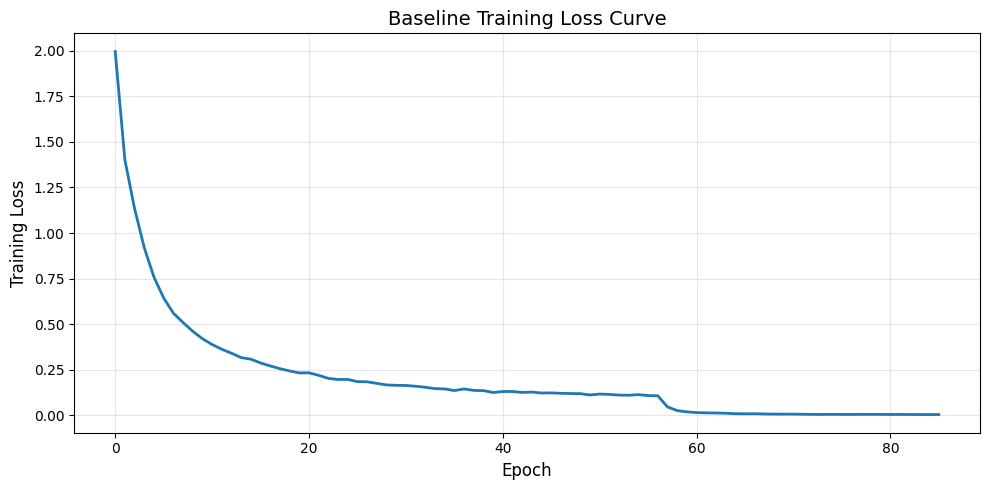

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Baseline Training Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../results/figures/baseline_training_loss.png', dpi=150)
plt.show()

### Save Baseline Model

In [9]:
# Save baseline model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'test_accuracy': test_accuracy,
    'test_loss': test_loss,
    'epochs': epochs,
}, '../../results/checkpoints/baseline_model.pth')

print("Baseline model saved to results/checkpoints/baseline_model.pth")

Baseline model saved to results/checkpoints/baseline_model.pth


## 5. Iterative Pruning Experiments

Run the main pruning experiment from the paper.

In [10]:
# Get pruning configuration for your model
# Options: 'lenet', 'conv2', 'conv4', 'conv6', 'resnet18'

# pruning_config = get_pruning_config('conv2')  # Change this for your model
pruning_config = get_pruning_config('resnet18')

print("Pruning Configuration:")
for key, value in pruning_config.items():
    print(f"  {key}: {value}")

# Or customize your own config
# pruning_config = {
#     'prune_rate_conv': 0.1,
#     'prune_rate_fc': 0.2,
#     'pruning_strategy': 'layerwise'
# }

Pruning Configuration:
  prune_rate_conv: 0.2
  prune_rate_fc: 0.0
  pruning_strategy: global
  description: ResNet-18 for CIFAR-10


In [11]:
# Create fresh model for pruning
# model_pruning = Conv2().to(device)  # Replace with your model
model_pruning = ResNet18_CIFAR10().to(device)  # Replace with your model

# Run iterative pruning
# results = iterative_pruning(
#     model=model_pruning,
#     train_loader=train_loader,
#     test_loader=test_loader,
#     optimizer_class=torch.optim.Adam,
#     optimizer_kwargs={'lr': learning_rate},
#     device=device,
#     config=pruning_config,
#     n_rounds=10,           # Start with 10 rounds for testing
#     epochs_per_round=20,   # Epochs per pruning round
#     verbose=True
# )
epochs_per_round = 86  # 之前计算的 (30k iter / 352 steps)

results = iterative_pruning(
    model=model_pruning,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={'lr': 0.1, 'momentum': 0.9, 'weight_decay': 1e-4},
    device=device,
    config=pruning_config,
    n_rounds=15,          # 剪枝 15 轮
    epochs_per_round=epochs_per_round,  # 每一轮训练 30k iterations
    verbose=True
)

print("\nPruning experiment complete!")

Starting Iterative Pruning
Initial parameters: 11,173,962
Pruning strategy: global
Conv prune rate: 20.0%
FC prune rate: 0.0%

Round 1/15


Epoch 1/86: 100%|██████████| 352/352 [00:16<00:00, 20.89it/s] 


Epoch 1/86, Loss: 2.0121


Epoch 2/86: 100%|██████████| 352/352 [00:19<00:00, 18.13it/s]


Epoch 2/86, Loss: 1.4679


...

Epoch 29/86, Loss: 0.1725


Epoch 30/86: 100%|██████████| 352/352 [00:19<00:00, 17.96it/s]


Epoch 30/86, Loss: 0.1670


Epoch 31/86:  99%|█████████▊| 347/352 [00:16<00:00, 20.86it/s] 


KeyboardInterrupt: 

## 6. Analyze Results

Visualize and analyze the pruning results.

In [ ]:
# Extract data for plotting
rounds = [r['round'] for r in results]
test_accuracies = [r['test_accuracy'] for r in results]
remaining_params_pct = [r['remaining_params_pct'] for r in results]
remaining_params = [r['remaining_params'] for r in results]

# Print summary
print("\n" + "="*70)
print("Pruning Results Summary")
print("="*70)
print(f"{'Round':<8} {'Params %':<12} {'Params':<15} {'Test Acc %':<12}")
print("-"*70)
for r in results:
    print(f"{r['round']:<8} {r['remaining_params_pct']:<12.2f} "
          f"{r['remaining_params']:<15,} {r['test_accuracy']:<12.2f}")
print("="*70)

In [ ]:
# Visualize results (similar to paper Figure 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Test Accuracy vs Sparsity
ax1.plot(remaining_params_pct, test_accuracies, 'o-', linewidth=2, markersize=8)
# ax1.axhline(y=test_accuracy, color='r', linestyle='--', label='Baseline', alpha=0.7) # If you are using CPU, use this line
ax1.axhline(y=test_accuracy.item(), color='r', linestyle='--', label='Baseline', alpha=0.7) # If you are using GPU (cuda), use this line
ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Test Accuracy vs Sparsity', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.invert_xaxis()  # More sparse on the right

# Right plot: Parameters Remaining
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction over Rounds', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('../../results/figures/pruning_results.png', dpi=150)
plt.show()

print("\nFigure saved to results/figures/pruning_results.png")

## 7. Identify Winning Tickets

Find which pruned networks are "winning tickets" (match or exceed baseline accuracy).

In [ ]:
# Identify winning tickets
baseline_accuracy = test_accuracy
winning_tickets = []

for r in results:
    # Winning ticket criteria: accuracy >= 98% of baseline
    if r['test_accuracy'] >= baseline_accuracy * 0.98:
        winning_tickets.append(r)

print(f"\n{'='*70}")
print(f"Found {len(winning_tickets)} Winning Tickets!")
print(f"{'='*70}")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"\nWinning Tickets (accuracy >= {baseline_accuracy * 0.98:.2f}%):")
print(f"{'Round':<8} {'Sparsity %':<12} {'Params':<15} {'Accuracy %':<12}")
print("-"*70)

for ticket in winning_tickets:
    sparsity = 100 - ticket['remaining_params_pct']
    print(f"{ticket['round']:<8} {sparsity:<12.1f} "
          f"{ticket['remaining_params']:<15,} {ticket['test_accuracy']:<12.2f}")

if winning_tickets:
    best_ticket = min(winning_tickets, key=lambda x: x['remaining_params'])
    print(f"\nBest Winning Ticket:")
    print(f"  Round: {best_ticket['round']}")
    print(f"  Sparsity: {100 - best_ticket['remaining_params_pct']:.1f}%")
    print(f"  Parameters: {best_ticket['remaining_params']:,}")
    print(f"  Accuracy: {best_ticket['test_accuracy']:.2f}%")

## 8. Save Results

In [ ]:
import json

# Save results to JSON
results_dict = {
    'model': 'Conv2',  # Change this
    'dataset': 'CIFAR-10',
    'baseline_accuracy': float(baseline_accuracy),
    'pruning_config': pruning_config,
    'pruning_results': results,
    'winning_tickets': winning_tickets
}

with open('../../results/pruning_results.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print("Results saved to results/pruning_results.json")

## 9. Next Steps

### Experiment Ideas:

1. **Compare pruning strategies**
   - Try different `prune_rate_conv` and `prune_rate_fc`
   - Compare `layerwise` vs `global` pruning

2. **Random reinitialization baseline**
   - Use `random_reinit_pruning()` to show winning tickets need original initialization

3. **One-shot pruning**
   - Compare `one_shot_pruning()` vs iterative pruning

4. **Visualize weight distributions**
   - Plot weight magnitude histograms before/after pruning

5. **Learning rate experiments**
   - Test different learning rates (paper shows this matters!)

## Notes and Observations

**TODO: Add your observations here**

- What worked well?
- What surprised you?
- Any implementation challenges?
- Ideas for the final report?